In [1]:
"""
Outsourcing 描述性统计分析
任务1：企业"真实生产"与销售的分布差异
任务2：Outsourcing的普遍性与强度

数据结构：
- firm_id: 企业标识
- product_id: 产品标识
- is_output: 1=产出, 0=投入
- v: 交易金额
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


# =============================================================================
# 数据加载与Outsourcing识别
# =============================================================================

def load_data(filepath, usecols=['firm_id', 'product_id', 'is_output', 'v']):
    """
    读取dta文件，只加载必要的列以节省内存
    """
    print(f"正在读取数据: {filepath}")
    df = pd.read_stata(filepath, columns=usecols)
    
    # 优化内存
    df['is_output'] = df['is_output'].astype('int8')
    
    print(f"数据形状: {df.shape}")
    print(f"内存占用: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
    
    return df


def identify_outsourcing(df):
    """
    识别outsourcing行为：
    同一firm_id下，同一product_id既出现在产出端(is_output=1)又出现在投入端(is_output=0)
    """
    print("\n=== 识别Outsourcing ===")
    
    # 按firm-product分组，检查是否同时存在input和output
    firm_product_io = df.groupby(['firm_id', 'product_id'])['is_output'].agg(['min', 'max'])
    
    # outsourcing条件：min=0 (有input) 且 max=1 (有output)
    outsourcing_mask = (firm_product_io['min'] == 0) & (firm_product_io['max'] == 1)
    outsourcing_pairs = firm_product_io[outsourcing_mask].reset_index()[['firm_id', 'product_id']]
    outsourcing_pairs['is_outsourcing'] = 1
    
    print(f"Outsourcing的firm-product组合数: {len(outsourcing_pairs):,}")
    print(f"涉及的企业数: {outsourcing_pairs['firm_id'].nunique():,}")
    print(f"涉及的产品数: {outsourcing_pairs['product_id'].nunique():,}")
    
    # 将outsourcing标记合并回原数据
    df_with_flag = df.merge(outsourcing_pairs, on=['firm_id', 'product_id'], how='left')
    df_with_flag['is_outsourcing'] = df_with_flag['is_outsourcing'].fillna(0).astype('int8')
    
    return outsourcing_pairs, df_with_flag


# =============================================================================
# 任务1：企业"真实生产"与销售的分布差异
# =============================================================================

def task1_production_vs_sales(df_with_flag, output_dir):
    """
    任务1：比较企业真实生产与销售的分布差异
    
    - 总销售额 = 所有产出端交易额
    - 真实生产额 = 总销售额 - outsourcing产品的销售额（因为outsourcing产品是买来再卖的）
    """
    print("\n" + "="*60)
    print("任务1：企业'真实生产'与销售的分布差异")
    print("="*60)
    
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # 只看产出端
    output_df = df_with_flag[df_with_flag['is_output'] == 1].copy()
    
    # 企业层面汇总
    firm_stats = output_df.groupby('firm_id').agg(
        total_sales=('v', 'sum'),  # 总销售额
        outsourcing_sales=('v', lambda x: x[output_df.loc[x.index, 'is_outsourcing'] == 1].sum())
    ).reset_index()
    
    # 更高效的写法
    firm_total_sales = output_df.groupby('firm_id')['v'].sum().rename('total_sales')
    firm_outsourcing_sales = output_df[output_df['is_outsourcing'] == 1].groupby('firm_id')['v'].sum().rename('outsourcing_sales')
    
    firm_stats = pd.concat([firm_total_sales, firm_outsourcing_sales], axis=1).fillna(0)
    firm_stats['true_production'] = firm_stats['total_sales'] - firm_stats['outsourcing_sales']
    firm_stats['ratio'] = firm_stats['true_production'] / firm_stats['total_sales']
    firm_stats = firm_stats.reset_index()
    
    # 处理异常值
    firm_stats['ratio'] = firm_stats['ratio'].replace([np.inf, -np.inf], np.nan)
    firm_stats = firm_stats[firm_stats['total_sales'] > 0]  # 排除销售额为0的企业
    
    print(f"\n企业数: {len(firm_stats):,}")
    print(f"\n--- 总销售额统计 ---")
    print(f"均值: {firm_stats['total_sales'].mean():,.0f}")
    print(f"中位数: {firm_stats['total_sales'].median():,.0f}")
    print(f"标准差: {firm_stats['total_sales'].std():,.0f}")
    
    print(f"\n--- 真实生产额统计 ---")
    print(f"均值: {firm_stats['true_production'].mean():,.0f}")
    print(f"中位数: {firm_stats['true_production'].median():,.0f}")
    print(f"标准差: {firm_stats['true_production'].std():,.0f}")
    
    print(f"\n--- 真实生产/总销售 比值统计 ---")
    print(f"均值: {firm_stats['ratio'].mean():.4f}")
    print(f"中位数: {firm_stats['ratio'].median():.4f}")
    print(f"标准差: {firm_stats['ratio'].std():.4f}")
    print(f"比值=1的企业占比（无outsourcing）: {(firm_stats['ratio'] == 1).mean():.2%}")
    print(f"比值<1的企业占比（有outsourcing）: {(firm_stats['ratio'] < 1).mean():.2%}")
    
    # --- 绘图 ---
    
    # 图1：总销售额 vs 真实生产额的密度分布（对数尺度）
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 对数变换（排除0和负值）
    log_sales = np.log10(firm_stats['total_sales'][firm_stats['total_sales'] > 0])
    log_production = np.log10(firm_stats['true_production'][firm_stats['true_production'] > 0])
    
    axes[0].hist(log_sales, bins=50, alpha=0.6, label='总销售额', density=True)
    axes[0].hist(log_production, bins=50, alpha=0.6, label='真实生产额', density=True)
    axes[0].set_xlabel('log10(金额)', fontsize=12)
    axes[0].set_ylabel('密度', fontsize=12)
    axes[0].set_title('总销售额 vs 真实生产额分布（对数尺度）', fontsize=14)
    axes[0].legend()
    
    # 图2：比值分布
    ratio_valid = firm_stats['ratio'].dropna()
    axes[1].hist(ratio_valid, bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(ratio_valid.mean(), color='red', linestyle='--', label=f'均值: {ratio_valid.mean():.3f}')
    axes[1].axvline(ratio_valid.median(), color='orange', linestyle='--', label=f'中位数: {ratio_valid.median():.3f}')
    axes[1].set_xlabel('真实生产额 / 总销售额', fontsize=12)
    axes[1].set_ylabel('频数', fontsize=12)
    axes[1].set_title('真实生产/销售比值分布', fontsize=14)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(output_dir / 'task1_production_vs_sales.png', dpi=150, bbox_inches='tight')
    print(f"\n图片已保存: {output_dir / 'task1_production_vs_sales.png'}")
    plt.show()
    
    # 图3：散点图（总销售额 vs 真实生产额）
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 采样以避免过多点
    sample_size = min(50000, len(firm_stats))
    sample = firm_stats.sample(sample_size, random_state=42)
    
    ax.scatter(np.log10(sample['total_sales'] + 1), 
               np.log10(sample['true_production'] + 1), 
               alpha=0.3, s=5)
    
    # 45度线
    max_val = max(np.log10(sample['total_sales'] + 1).max(), 
                  np.log10(sample['true_production'] + 1).max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='45度线（无outsourcing）')
    
    ax.set_xlabel('log10(总销售额)', fontsize=12)
    ax.set_ylabel('log10(真实生产额)', fontsize=12)
    ax.set_title('总销售额 vs 真实生产额（对数尺度）', fontsize=14)
    ax.legend()
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'task1_scatter_sales_vs_production.png', dpi=150, bbox_inches='tight')
    print(f"图片已保存: {output_dir / 'task1_scatter_sales_vs_production.png'}")
    plt.show()
    
    # 保存数据
    firm_stats.to_csv(output_dir / 'task1_firm_production_sales.csv', index=False)
    
    return firm_stats


# =============================================================================
# 任务2：Outsourcing的普遍性与强度
# =============================================================================

def task2_prevalence_and_intensity(df_with_flag, output_dir):
    """
    任务2：Outsourcing的普遍性与强度
    
    (a) 有outsourcing的企业占比
    (b) outsourcing收入占比分布（revenue share）
    (c) outsourcing投入占比分布（input share）
    (d) 截面异质性（行业间、企业间的离散程度）
    """
    print("\n" + "="*60)
    print("任务2：Outsourcing的普遍性与强度")
    print("="*60)
    
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # ----- 2a: 普遍性 -----
    print("\n--- 2a: Outsourcing普遍性 ---")
    
    total_firms = df_with_flag['firm_id'].nunique()
    
    # 有outsourcing的企业
    outsourcing_firms = df_with_flag[df_with_flag['is_outsourcing'] == 1]['firm_id'].nunique()
    
    prevalence = outsourcing_firms / total_firms
    
    print(f"总企业数: {total_firms:,}")
    print(f"有outsourcing的企业数: {outsourcing_firms:,}")
    print(f"占比: {prevalence:.2%}")
    
    # ----- 2b: Revenue Share（outsourcing销售额占总销售额）-----
    print("\n--- 2b: Outsourcing Revenue Share ---")
    
    output_df = df_with_flag[df_with_flag['is_output'] == 1]
    
    firm_total_sales = output_df.groupby('firm_id')['v'].sum().rename('total_sales')
    firm_outsourcing_sales = output_df[output_df['is_outsourcing'] == 1].groupby('firm_id')['v'].sum().rename('outsourcing_sales')
    
    revenue_share = pd.concat([firm_total_sales, firm_outsourcing_sales], axis=1).fillna(0)
    revenue_share['revenue_share'] = revenue_share['outsourcing_sales'] / revenue_share['total_sales']
    revenue_share['revenue_share'] = revenue_share['revenue_share'].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # 只看有outsourcing的企业
    revenue_share_positive = revenue_share[revenue_share['outsourcing_sales'] > 0]['revenue_share']
    
    print(f"所有企业的revenue share:")
    print(f"  均值: {revenue_share['revenue_share'].mean():.4f}")
    print(f"  中位数: {revenue_share['revenue_share'].median():.4f}")
    
    print(f"\n有outsourcing的企业的revenue share:")
    print(f"  均值: {revenue_share_positive.mean():.4f}")
    print(f"  中位数: {revenue_share_positive.median():.4f}")
    print(f"  标准差: {revenue_share_positive.std():.4f}")
    print(f"  25%分位: {revenue_share_positive.quantile(0.25):.4f}")
    print(f"  75%分位: {revenue_share_positive.quantile(0.75):.4f}")
    
    # ----- 2c: Input Share（outsourcing投入额占总投入额）-----
    print("\n--- 2c: Outsourcing Input Share ---")
    
    input_df = df_with_flag[df_with_flag['is_output'] == 0]
    
    firm_total_input = input_df.groupby('firm_id')['v'].sum().rename('total_input')
    firm_outsourcing_input = input_df[input_df['is_outsourcing'] == 1].groupby('firm_id')['v'].sum().rename('outsourcing_input')
    
    input_share = pd.concat([firm_total_input, firm_outsourcing_input], axis=1).fillna(0)
    input_share['input_share'] = input_share['outsourcing_input'] / input_share['total_input']
    input_share['input_share'] = input_share['input_share'].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    input_share_positive = input_share[input_share['outsourcing_input'] > 0]['input_share']
    
    print(f"所有企业的input share:")
    print(f"  均值: {input_share['input_share'].mean():.4f}")
    print(f"  中位数: {input_share['input_share'].median():.4f}")
    
    print(f"\n有outsourcing的企业的input share:")
    print(f"  均值: {input_share_positive.mean():.4f}")
    print(f"  中位数: {input_share_positive.median():.4f}")
    print(f"  标准差: {input_share_positive.std():.4f}")
    print(f"  25%分位: {input_share_positive.quantile(0.25):.4f}")
    print(f"  75%分位: {input_share_positive.quantile(0.75):.4f}")
    
    # ----- 2d: 截面异质性 -----
    print("\n--- 2d: 截面异质性（企业间离散程度）---")
    
    # 合并revenue share和input share
    firm_intensity = revenue_share[['revenue_share']].join(input_share[['input_share']], how='outer').fillna(0)
    
    print(f"Revenue share 变异系数 (CV): {revenue_share_positive.std() / revenue_share_positive.mean():.4f}")
    print(f"Input share 变异系数 (CV): {input_share_positive.std() / input_share_positive.mean():.4f}")
    
    # Gini系数
    def gini(x):
        x = np.array(x)
        x = x[x > 0]  # 只看正值
        if len(x) == 0:
            return np.nan
        x = np.sort(x)
        n = len(x)
        return (2 * np.sum((np.arange(1, n+1) * x)) - (n + 1) * np.sum(x)) / (n * np.sum(x))
    
    print(f"Revenue share Gini系数: {gini(revenue_share_positive):.4f}")
    print(f"Input share Gini系数: {gini(input_share_positive):.4f}")
    
    # ----- 绘图 -----
    
    # 图1: Revenue share 分布
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(revenue_share_positive, bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(revenue_share_positive.mean(), color='red', linestyle='--', 
                    label=f'均值: {revenue_share_positive.mean():.3f}')
    axes[0].axvline(revenue_share_positive.median(), color='orange', linestyle='--',
                    label=f'中位数: {revenue_share_positive.median():.3f}')
    axes[0].set_xlabel('Outsourcing Revenue Share', fontsize=12)
    axes[0].set_ylabel('频数', fontsize=12)
    axes[0].set_title('Outsourcing收入占比分布（有outsourcing的企业）', fontsize=14)
    axes[0].legend()
    
    axes[1].hist(input_share_positive, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[1].axvline(input_share_positive.mean(), color='red', linestyle='--',
                    label=f'均值: {input_share_positive.mean():.3f}')
    axes[1].axvline(input_share_positive.median(), color='orange', linestyle='--',
                    label=f'中位数: {input_share_positive.median():.3f}')
    axes[1].set_xlabel('Outsourcing Input Share', fontsize=12)
    axes[1].set_ylabel('频数', fontsize=12)
    axes[1].set_title('Outsourcing投入占比分布（有outsourcing的企业）', fontsize=14)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(output_dir / 'task2_share_distributions.png', dpi=150, bbox_inches='tight')
    print(f"\n图片已保存: {output_dir / 'task2_share_distributions.png'}")
    plt.show()
    
    # 图2: Revenue share vs Input share 散点图
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 只看有outsourcing的企业
    firms_with_outsourcing = firm_intensity[(firm_intensity['revenue_share'] > 0) | (firm_intensity['input_share'] > 0)]
    
    sample_size = min(50000, len(firms_with_outsourcing))
    sample = firms_with_outsourcing.sample(sample_size, random_state=42)
    
    ax.scatter(sample['input_share'], sample['revenue_share'], alpha=0.3, s=5)
    ax.plot([0, 1], [0, 1], 'r--', label='45度线')
    ax.set_xlabel('Outsourcing Input Share', fontsize=12)
    ax.set_ylabel('Outsourcing Revenue Share', fontsize=12)
    ax.set_title('Input Share vs Revenue Share', fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'task2_input_vs_revenue_share.png', dpi=150, bbox_inches='tight')
    print(f"图片已保存: {output_dir / 'task2_input_vs_revenue_share.png'}")
    plt.show()
    
    # 图3: 按revenue share分组的企业数量
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    revenue_share_all = revenue_share['revenue_share']
    
    counts, edges = np.histogram(revenue_share_all[revenue_share_all > 0], bins=bins)
    
    ax.bar(range(len(counts)), counts, tick_label=[f'{bins[i]:.0%}-{bins[i+1]:.0%}' for i in range(len(bins)-1)])
    ax.set_xlabel('Revenue Share 区间', fontsize=12)
    ax.set_ylabel('企业数量', fontsize=12)
    ax.set_title('按Outsourcing Revenue Share分组的企业数量', fontsize=14)
    plt.xticks(rotation=45)
    
    # 添加数值标签
    for i, count in enumerate(counts):
        ax.text(i, count + max(counts)*0.01, f'{count:,}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'task2_revenue_share_bins.png', dpi=150, bbox_inches='tight')
    print(f"图片已保存: {output_dir / 'task2_revenue_share_bins.png'}")
    plt.show()
    
    # 保存数据
    firm_intensity.to_csv(output_dir / 'task2_firm_intensity.csv')
    
    # 汇总统计表
    summary = pd.DataFrame({
        '指标': ['总企业数', '有outsourcing的企业数', 'Outsourcing普遍率',
                 'Revenue Share均值（有outsourcing）', 'Revenue Share中位数（有outsourcing）',
                 'Input Share均值（有outsourcing）', 'Input Share中位数（有outsourcing）',
                 'Revenue Share变异系数', 'Input Share变异系数'],
        '值': [total_firms, outsourcing_firms, prevalence,
               revenue_share_positive.mean(), revenue_share_positive.median(),
               input_share_positive.mean(), input_share_positive.median(),
               revenue_share_positive.std() / revenue_share_positive.mean(),
               input_share_positive.std() / input_share_positive.mean()]
    })
    summary.to_csv(output_dir / 'task2_summary.csv', index=False)
    
    return {
        'prevalence': prevalence,
        'revenue_share': revenue_share,
        'input_share': input_share,
        'firm_intensity': firm_intensity,
        'summary': summary
    }


# =============================================================================
# 主函数
# =============================================================================

def main(data_path, output_dir='./outsourcing_results'):
    """
    主分析流程
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # 1. 加载数据
    df = load_data(data_path)
    
    # 2. 识别outsourcing
    outsourcing_pairs, df_with_flag = identify_outsourcing(df)
    
    # 保存outsourcing pairs
    outsourcing_pairs.to_csv(output_dir / 'outsourcing_pairs.csv', index=False)
    
    # 3. 任务1：生产vs销售分布
    task1_results = task1_production_vs_sales(df_with_flag, output_dir)
    
    # 4. 任务2：普遍性与强度
    task2_results = task2_prevalence_and_intensity(df_with_flag, output_dir)
    
    print("\n" + "="*60)
    print("分析完成！")
    print("="*60)
    
    return {
        'outsourcing_pairs': outsourcing_pairs,
        'df_with_flag': df_with_flag,
        'task1': task1_results,
        'task2': task2_results
    }


正在读取数据: G:/Kuangyu_Temp/Outsource/lenth9.dta
数据形状: (357989254, 4)
内存占用: 50.04 GB

=== 识别Outsourcing ===
Outsourcing的firm-product组合数: 29,866,924
涉及的企业数: 4,926,597
涉及的产品数: 2,742

任务1：企业'真实生产'与销售的分布差异

企业数: 7,191,162

--- 总销售额统计 ---
均值: 58,289,743
中位数: 3,393,911
标准差: 1,489,400,265

--- 真实生产额统计 ---
均值: 8,053,566
中位数: 572,472
标准差: 422,814,761

--- 真实生产/总销售 比值统计 ---
均值: 0.5032
中位数: 0.4651
标准差: 0.4365
比值=1的企业占比（无outsourcing）: 31.49%
比值<1的企业占比（有outsourcing）: 68.51%

图片已保存: G:\Kuangyu_Temp\Outsource\outsourcing_results\task1_production_vs_sales.png


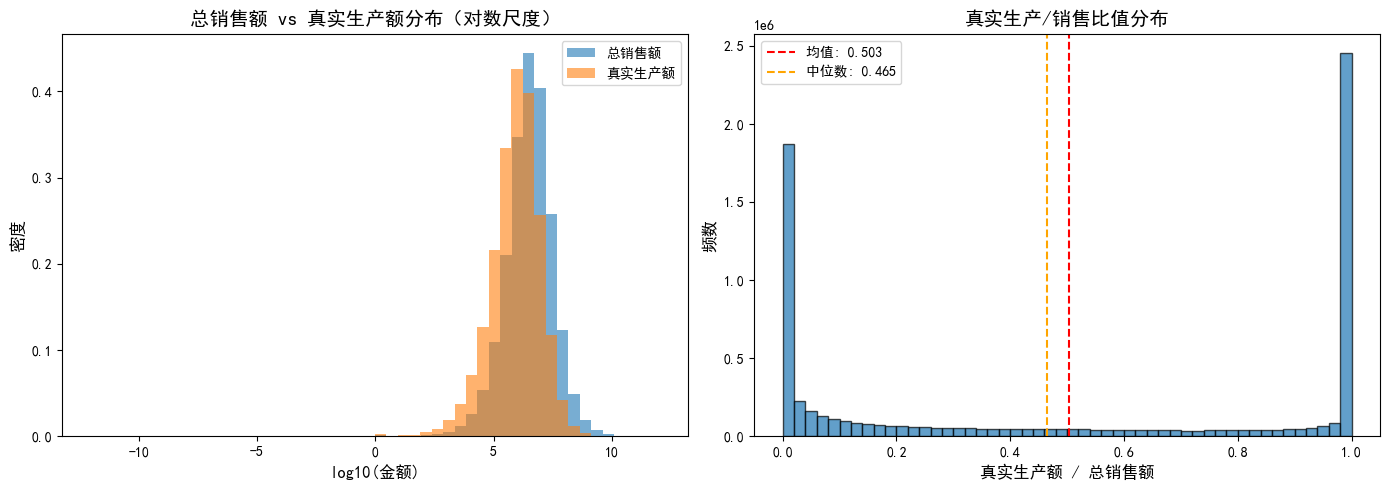

图片已保存: G:\Kuangyu_Temp\Outsource\outsourcing_results\task1_scatter_sales_vs_production.png


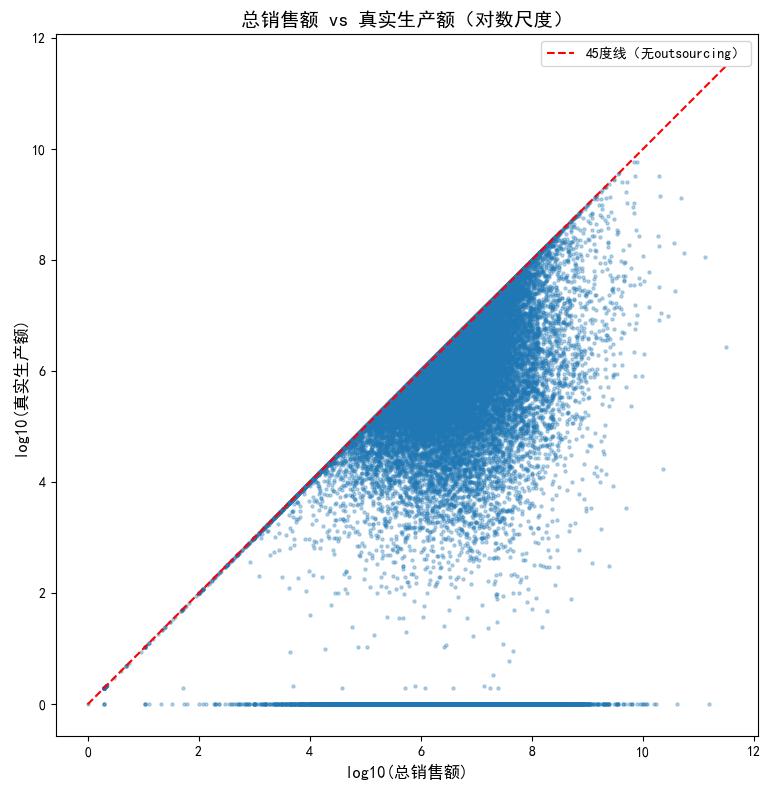


任务2：Outsourcing的普遍性与强度

--- 2a: Outsourcing普遍性 ---
总企业数: 7,191,162
有outsourcing的企业数: 4,926,597
占比: 68.51%

--- 2b: Outsourcing Revenue Share ---
所有企业的revenue share:
  均值: 0.4968
  中位数: 0.5349

有outsourcing的企业的revenue share:
  均值: 0.7252
  中位数: 0.9060
  标准差: 0.3355
  25%分位: 0.4917
  75%分位: 1.0000

--- 2c: Outsourcing Input Share ---
所有企业的input share:
  均值: 0.3332
  中位数: 0.1595

有outsourcing的企业的input share:
  均值: 0.4863
  中位数: 0.4796
  标准差: 0.3486
  25%分位: 0.1380
  75%分位: 0.8270

--- 2d: 截面异质性（企业间离散程度）---
Revenue share 变异系数 (CV): 0.4626
Input share 变异系数 (CV): 0.7167
Revenue share Gini系数: 0.2425
Input share Gini系数: 0.4111

图片已保存: G:\Kuangyu_Temp\Outsource\outsourcing_results\task2_share_distributions.png


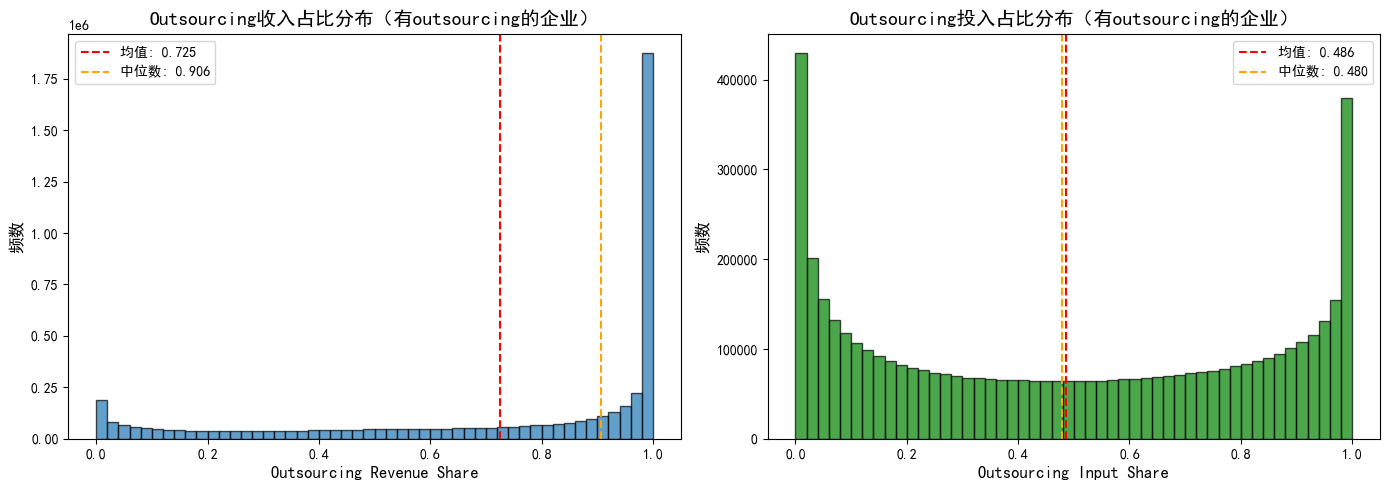

图片已保存: G:\Kuangyu_Temp\Outsource\outsourcing_results\task2_input_vs_revenue_share.png


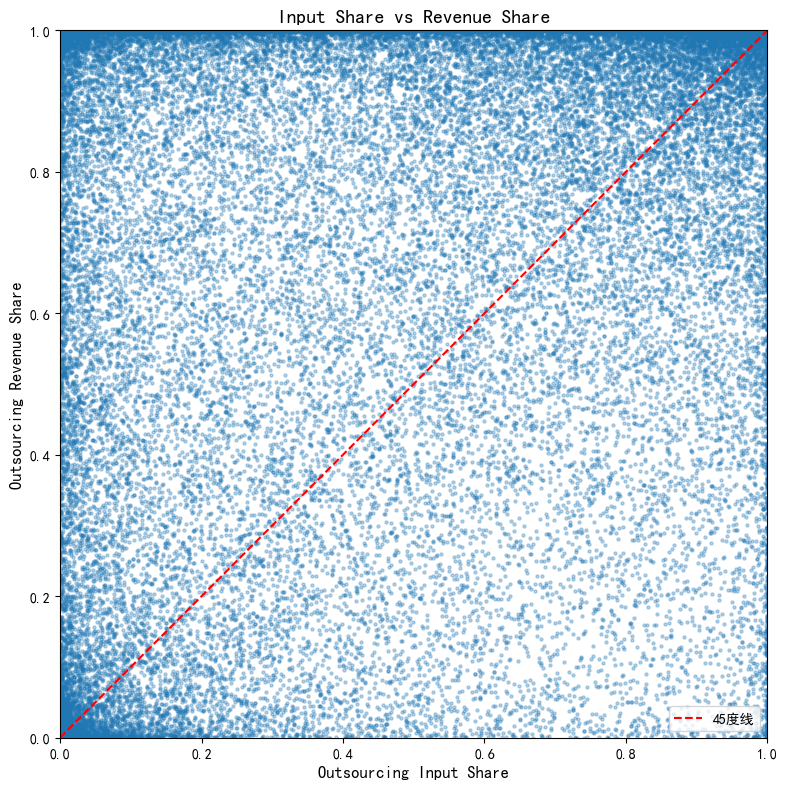

图片已保存: G:\Kuangyu_Temp\Outsource\outsourcing_results\task2_revenue_share_bins.png


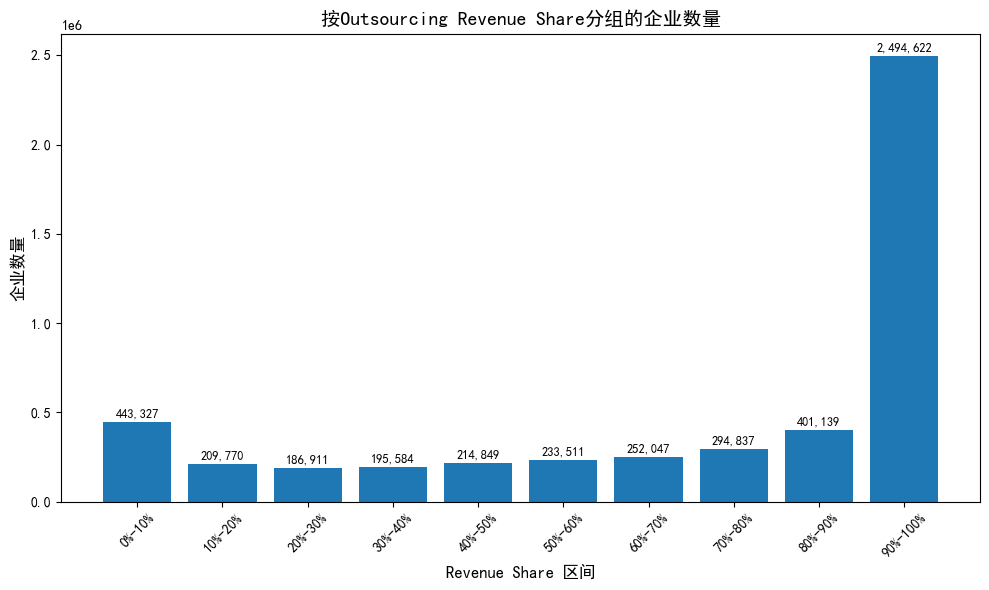


分析完成！


In [2]:

if __name__ == "__main__":
    # 修改为你的数据路径
    DATA_PATH = "G:/Kuangyu_Temp/Outsource/lenth9.dta"
    OUTPUT_DIR = "G:/Kuangyu_Temp/Outsource/outsourcing_results"
    
    results = main(DATA_PATH, OUTPUT_DIR)